In [ ]:
# Install system unrar and Python packages
!apt-get install -y unrar > /dev/null 2>&1
!pip install -q rarfile patool opencv-python-headless albumentations pytorch-lightning

import os, sys, shutil
print("Python:", sys.version)
print("unrar installed:", os.system("which unrar") == 0)
USE_DRIVE         = False    # True  → copy from Google Drive
                            # False → upload files directly to Colab

GDRIVE_FOLDER     = "tag_boundary_detection_training_data"
GDRIVE_SOURCE_DIR  = f"/content/drive/My Drive/{GDRIVE_FOLDER}"
LOCAL_DOWNLOAD_DIR = "/content/downloads"
EXTRACT_DIR        = "/content/dataset"

os.makedirs(LOCAL_DOWNLOAD_DIR, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

REQUIRED_FILES = ["flash_images.rar", "train_corners.csv", "val_corners.csv"]

if USE_DRIVE:
    from google.colab import drive
    print("Connecting to Google Drive...")
    drive.mount('/content/drive')
    print(f"Drive mounted. Copying files from '{GDRIVE_SOURCE_DIR}' ...")
    for filename in REQUIRED_FILES:
        src = os.path.join(GDRIVE_SOURCE_DIR, filename)
        dst = os.path.join(LOCAL_DOWNLOAD_DIR, filename)
        if not os.path.exists(src):
            raise FileNotFoundError(
                f"\n '{filename}' not found at: {src}\n"
                f"Please upload it to your Drive folder named: '{GDRIVE_FOLDER}'"
            )
        shutil.copy(src, dst)
        print(f"Copied: {filename}")
    drive.flush_and_unmount()
    print("Drive unmounted. All files are in Colab local storage.")
else:
    print("Direct upload mode. Checking Colab storage...")
    for filename in REQUIRED_FILES:
        dst = os.path.join(LOCAL_DOWNLOAD_DIR, filename)
        if not os.path.exists(dst) and os.path.exists(f"/content/{filename}"):
            shutil.copy(f"/content/{filename}", dst)
        if not os.path.exists(dst):
            raise FileNotFoundError(
                f"\n '{filename}' not found.\n"
                "Please upload it via the Files panel on the left, then re-run this cell."
            )
        print(f"Found: {filename}")

RAR_PATH       = os.path.join(LOCAL_DOWNLOAD_DIR, "flash_images.rar")
TRAIN_CSV_PATH = os.path.join(LOCAL_DOWNLOAD_DIR, "train_corners.csv")
VAL_CSV_PATH   = os.path.join(LOCAL_DOWNLOAD_DIR, "val_corners.csv")
print("\nAll files ready")


In [ ]:
import rarfile

# Extract flash_images.rar into Colab local storage
print(f"Extracting '{RAR_PATH}' → '{EXTRACT_DIR}' ...")
try:
    ret = os.system(f"unrar x -y '{RAR_PATH}' '{EXTRACT_DIR}/'")
    if ret != 0:
        print("System unrar failed, trying rarfile library...")
        with rarfile.RarFile(RAR_PATH) as rf:
            rf.extractall(EXTRACT_DIR)
    print("Extraction complete")
except Exception as e:
    print(f"ERROR during extraction: {e}")
    raise

# Collect all image paths
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
all_images = []
for root, dirs, files_ in os.walk(EXTRACT_DIR):
    for f in files_:
        if os.path.splitext(f)[1].lower() in IMAGE_EXTS:
            p = os.path.join(root, f)
            if p not in all_images:
                all_images.append(p)

print(f"  Images found       : {len(all_images)}")
print(f"  train_corners.csv  : {TRAIN_CSV_PATH}")
print(f"  val_corners.csv    : {VAL_CSV_PATH}")


In [ ]:
import pandas as pd
import numpy as np

# CSV format: two columns → 'filename' and 'corners'
# 'corners' is a space-separated string of 8 floats: x1 y1 x2 y2 x3 y3 x4 y4

def parse_corners(s):
    """Parse a space-separated string of 8 corner values into a float32 array."""
    vals = [float(x) for x in str(s).strip().split()]
    if len(vals) != 8:
        raise ValueError(f"Expected 8 corner values, got {len(vals)}: '{s}'")
    return np.array(vals, dtype=np.float32)

def load_csv(path):
    """Load a corners CSV and return a dict: basename → {corners, has_tag}."""
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]

    if "filename" not in df.columns or "corners" not in df.columns:
        raise ValueError(
            f"CSV must have 'filename' and 'corners' columns. Found: {df.columns.tolist()}"
        )

    df["corners_parsed"] = df["corners"].apply(parse_corners)
    # has_tag = True if any corner value is non-zero
    df["has_tag"] = df["corners_parsed"].apply(lambda arr: not np.all(arr == 0))
    # Normalize to basename only
    df["filename"] = df["filename"].apply(lambda p: os.path.basename(str(p)))

    result = {}
    for _, row in df.iterrows():
        result[row["filename"]] = {
            "corners": row["corners_parsed"],
            "has_tag": bool(row["has_tag"]),
        }
    return result

# Load both CSVs
print(f"Loading train CSV : {TRAIN_CSV_PATH}")
train_annot = load_csv(TRAIN_CSV_PATH)

print(f"Loading val CSV   : {VAL_CSV_PATH}")
val_annot   = load_csv(VAL_CSV_PATH)

# Combined dict used for visualization and classical sections
annot_dict = {**train_annot, **val_annot}

# Summary
for split, d in [("Train", train_annot), ("Val", val_annot), ("Total", annot_dict)]:
    n_tag = sum(1 for v in d.values() if v["has_tag"])
    print(f"  {split:6s}: {len(d):4d} images  ({n_tag} with tag, {len(d)-n_tag} without)")

print("\nSample train entry:", next(iter(train_annot.items())))


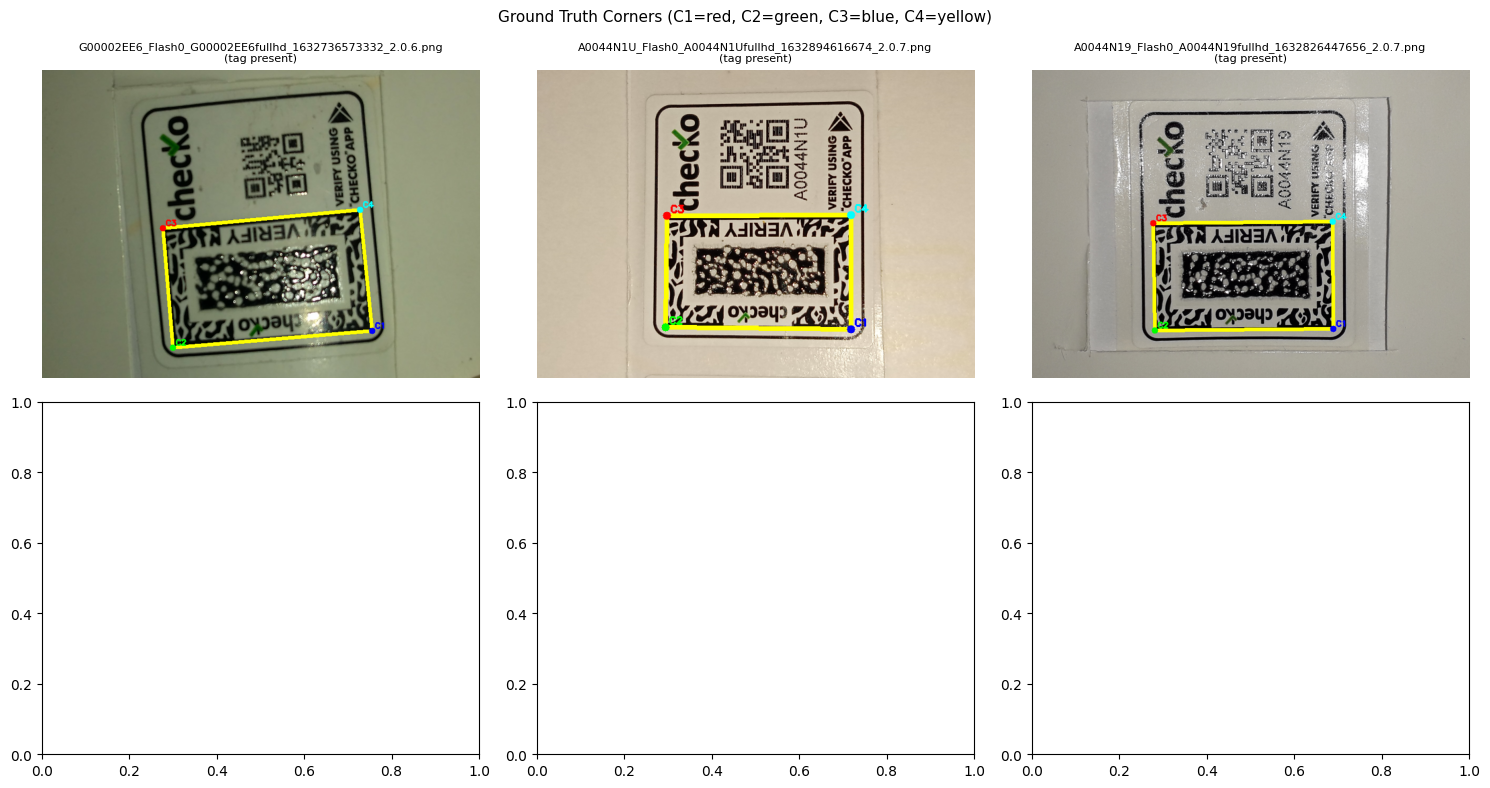

In [7]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

COLORS = [(255,0,0),(0,255,0),(0,0,255),(255,255,0)]  # BGR per corner
LABELS = ["C1","C2","C3","C4"]

def draw_corners(img_bgr, corners_xy8, color_list=COLORS):
    """Draw 4 labelled corner points and connecting polygon on a copy of img."""
    out = img_bgr.copy()
    pts = corners_xy8.reshape(4, 2).astype(int)
    cv2.polylines(out, [pts], isClosed=True, color=(0,255,255), thickness=5)
    for i, (pt, col) in enumerate(zip(pts, color_list)):
        cv2.circle(out, tuple(pt), 6, col, -1)
        cv2.putText(out, LABELS[i], tuple(pt + [5,-5]),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 2)
    return out

def show_samples(n=6):
    sample_files = [p for p in all_images if os.path.basename(p) in annot_dict]
    with_tag    = [p for p in sample_files if annot_dict[os.path.basename(p)]["has_tag"]]
    without_tag = [p for p in sample_files if not annot_dict[os.path.basename(p)]["has_tag"]]

    picks = random.sample(with_tag, min(n//2, len(with_tag))) + \
            random.sample(without_tag, min(n//2, len(without_tag)))
    random.shuffle(picks)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, path in zip(axes.flatten(), picks[:6]):
        img = cv2.imread(path)
        fname = os.path.basename(path)
        info  = annot_dict.get(fname, {"corners": np.zeros(8), "has_tag": False})
        if info["has_tag"]:
            img = draw_corners(img, info["corners"])
            title = f"{fname}\n(tag present)"
        else:
            title = f"{fname}\n(NO tag)"
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=8)
        ax.axis("off")
    plt.suptitle("Ground Truth Corners (C1=red, C2=green, C3=blue, C4=yellow)", fontsize=11)
    plt.tight_layout()
    plt.show()

show_samples(6)

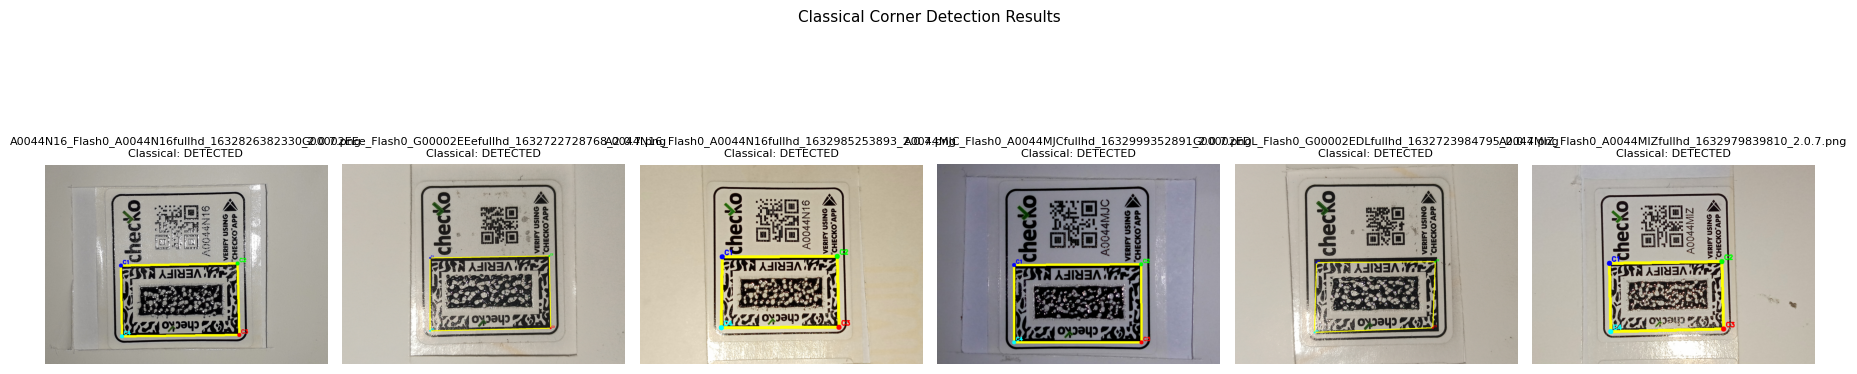

In [10]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

def order_corners(pts):
    """Order 4 points as: top-left, top-right, bottom-right, bottom-left."""
    pts = pts.reshape(4, 2)
    s   = pts.sum(axis=1)
    d   = np.diff(pts, axis=1).ravel()
    return np.array([pts[s.argmin()],   # TL
                     pts[d.argmin()],   # TR
                     pts[s.argmax()],   # BR
                     pts[d.argmax()]],  # BL
                    dtype=np.float32)

def preprocess_for_classical(img_bgr):
    """
    Advanced preprocessing using CLAHE (for lighting) and Bilateral Filtering (for sharp edges).
    """
    # 1. Convert to LAB color space to fix lighting on the Lightness channel
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # Apply CLAHE to normalize shadows and bright spots
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    # Merge back
    limg = cv2.merge((cl,a,b))
    enhanced_bgr = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # 2. Grayscale
    gray = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2GRAY)

    # 3. Bilateral Filter: Removes noise but keeps tag edges razor sharp
    blurred = cv2.bilateralFilter(gray, 9, 75, 75)

    # 4. Dynamic Canny Edge Detection
    v = np.median(blurred)
    sigma = 0.33
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edges = cv2.Canny(blurred, lower, upper)

    # Close small gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

    return gray, blurred, edges


def classical_detect_corners(img_bgr,
                             min_area_ratio=0.015,
                             max_area_ratio=0.30):
    """
    Highly robust corner detection using adaptive thresholding and rotated rectangles.
    """
    h, w = img_bgr.shape[:2]
    img_area = h * w

    # Use our new super-robust preprocessing
    _, _, processed_edges = preprocess_for_classical(img_bgr)

    contours, _ = cv2.findContours(processed_edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    valid_quads = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area < min_area_ratio * img_area or area > max_area_ratio * img_area:
            continue

        peri = cv2.arcLength(cnt, True)

        # Loop through epsilon values to smooth out noisy outer edges
        for eps in [0.03]:
            approx = cv2.approxPolyDP(cnt, eps * peri, True)

            if len(approx) == 4 and cv2.isContourConvex(approx):

                # --- ROTATION-SAFE ASPECT RATIO CHECK ---
                # minAreaRect returns (center(x, y), (width, height), angle of rotation)
                rect = cv2.minAreaRect(approx)
                rect_w, rect_h = rect[1]

                # Avoid division by zero
                if rect_w == 0 or rect_h == 0:
                    continue

                aspect_ratio = float(rect_w) / float(rect_h)

                # Tag should be somewhat square/rectangular, regardless of rotation
                if  1.0 <= aspect_ratio <= 2.5:
                    valid_quads.append((area, approx))
                    #break

    if not valid_quads:
        return None

    # Sort valid shapes by area (largest wins -> Outer Tag)
    valid_quads.sort(key=lambda x: x[0], reverse=True)
    #print('valid_quad',valid_quads)
    best_quad = valid_quads[0][1]

    return order_corners(best_quad.reshape(4, 2))


# ---------- Test on sample images ----------

n_show = 6
fig, axes = plt.subplots(1, n_show, figsize=(18, 5))
test_paths = random.sample(all_images, n_show)

for ax, path in zip(axes, test_paths):
    img   = cv2.imread(path)
    fname = os.path.basename(path)
    pts   = classical_detect_corners(img)
    vis   = img.copy()

    if pts is not None:
        vis = draw_corners(vis, pts.reshape(8), COLORS)
        #print('corners',pts)
        title = "Classical: DETECTED"
    else:
        title = "Classical: NO TAG"

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{fname}\n{title}", fontsize=8)
    ax.axis("off")

plt.suptitle("Classical Corner Detection Results", fontsize=11)
plt.tight_layout()
plt.show()


In [11]:

# Install PyTorch Lightning
!pip install -q pytorch-lightning

import pytorch_lightning as pl
print('PyTorch Lightning version:', pl.__version__)



PyTorch Lightning version: 2.6.1


In [ ]:
# Section 7 — Deep Learning: Dataset and DataLoader (using PyTorch Lightning)
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import numpy as np
import os
import random

# --- CONFIG ---
IMG_SIZE   = 512
BATCH_SIZE = 8
NUM_WORKERS= 2
VAL_SPLIT  = 0.15
SEED       = 42

class CornerDataset(Dataset):
    """
    Returns:
        image  : (3, IMG_SIZE, IMG_SIZE) float tensor
        coords : (8,) float tensor — normalised [0,1] corner coords (zeros if no tag)
        has_tag: (1,) float tensor — 1.0 if tag present, 0.0 otherwise
    """
    def __init__(self, image_paths, annot_dict, img_size=IMG_SIZE, augment=False):
        self.paths      = image_paths
        self.annot      = annot_dict
        self.img_size   = img_size
        self.augment    = augment
        self.base_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])
        self.aug_tf = T.Compose([
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            T.RandomGrayscale(p=0.05),
        ])
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        path  = self.paths[idx]
        fname = os.path.basename(path)
        img = Image.open(path).convert("RGB")
        orig_w, orig_h = img.size
        info    = self.annot.get(fname, {"corners": np.zeros(8, np.float32), "has_tag": False})
        has_tag = float(info["has_tag"])
        corners = info["corners"].copy()
        if has_tag:
            corners[0::2] /= orig_w
            corners[1::2] /= orig_h
        if self.augment:
            img = self.aug_tf(img)
        img_tensor = self.base_tf(img)
        return (img_tensor, torch.tensor(corners, dtype=torch.float32), torch.tensor([has_tag], dtype=torch.float32))

# --- Split train/val ---
random.seed(SEED)
all_annotated = [p for p in all_images if os.path.basename(p) in annot_dict]
random.shuffle(all_annotated)
n_val      = int(len(all_annotated) * VAL_SPLIT)
val_paths  = all_annotated[:n_val]
train_paths= all_annotated[n_val:]

train_ds = CornerDataset(train_paths, annot_dict, augment=True)
val_ds   = CornerDataset(val_paths,   annot_dict, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds)} images | Val: {len(val_ds)} images")

# Sanity check one batch
imgs, coords, has_tags = next(iter(train_loader))
print("Image tensor shape :", imgs.shape)
print("Coords tensor shape :", coords.shape)
print("has_tag tensor shape:", has_tags.shape)
print("Coord range         :", coords[has_tags[:,0]==1].min().item(), coords[has_tags[:,0]==1].max().item())


In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import torchvision.models as tvm

# --- LightningModule for Corner Detection ---
class CornerNetLightning(pl.LightningModule):
    def __init__(self, lr_head=1e-4, lr_backbone=1e-5, lambda_coord=10.0, lambda_conf=1.0, dropout=0.3, pretrained=True):
        super().__init__()
        self.save_hyperparameters()
        weights = tvm.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = tvm.resnet18(weights=weights)
        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.dec4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.dec3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(256, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.dec2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc_coords = nn.Linear(64, 8)
        self.fc_conf   = nn.Linear(64, 1)
        self.smooth_l1 = nn.SmoothL1Loss(reduction="none")
        self.bce_logit = nn.BCEWithLogitsLoss()

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.dec4(x)
        x = self.dec3(x)
        x = self.dec2(x)
        feat = self.drop(self.pool(x).flatten(1))
        coords = torch.sigmoid(self.fc_coords(feat))
        conf   = self.fc_conf(feat)
        return coords, conf

    def combined_loss(self, pred_coords, pred_conf, gt_coords, gt_has_tag):
        coord_loss_per = self.smooth_l1(pred_coords, gt_coords).mean(dim=1, keepdim=True)
        coord_loss     = (coord_loss_per * gt_has_tag).sum() / (gt_has_tag.sum() + 1e-6)
        conf_loss = self.bce_logit(pred_conf, gt_has_tag)
        total = self.hparams.lambda_coord * coord_loss + self.hparams.lambda_conf * conf_loss
        return total, coord_loss, conf_loss

    def training_step(self, batch, batch_idx):
        imgs, gt_coords, gt_has_tag = batch
        pred_coords, pred_conf = self(imgs)
        loss, closs, bloss = self.combined_loss(pred_coords, pred_conf, gt_coords, gt_has_tag)
        self.log('train_total', loss, on_step=False, on_epoch=True)
        self.log('train_coord', closs, on_step=False, on_epoch=True)
        self.log('train_conf', bloss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, gt_coords, gt_has_tag = batch
        pred_coords, pred_conf = self(imgs)
        loss, closs, bloss = self.combined_loss(pred_coords, pred_conf, gt_coords, gt_has_tag)
        self.log('val_total', loss, on_step=False, on_epoch=True)
        self.log('val_coord', closs, on_step=False, on_epoch=True)
        self.log('val_conf', bloss, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        backbone_params = list(self.stem.parameters()) + list(self.layer1.parameters()) + \
                          list(self.layer2.parameters()) + list(self.layer3.parameters()) + \
                          list(self.layer4.parameters())
        head_params = list(self.dec4.parameters()) + list(self.dec3.parameters()) + \
                      list(self.dec2.parameters()) + list(self.fc_coords.parameters()) + \
                      list(self.fc_conf.parameters())
        optimizer = torch.optim.AdamW([
            {"params": backbone_params, "lr": self.hparams.lr_backbone},
            {"params": head_params,     "lr": self.hparams.lr_head},
        ], weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
        return {"optimizer": optimizer, "lr_scheduler": scheduler, "monitor": "val_total"}


In [ ]:

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

# Save the best model (lowest val_total)
checkpoint_cb = ModelCheckpoint(
    monitor='val_total',
    save_top_k=1,
    mode='min',
    filename='best-cornernet',
    save_last=True
)

# Stop training if no improvement for 7 epochs
early_stop_cb = EarlyStopping(
    monitor='val_total',
    patience=7,
    mode='min',
    verbose=True
)

# Optional: log learning rate
lr_monitor = LearningRateMonitor(logging_interval='epoch')

# Instantiate the Lightning model
model = CornerNetLightning()

# Set up the PyTorch Lightning Trainer with mixed precision
trainer = pl.Trainer(
    max_epochs=50,                # More flexibility, will stop early if needed
    accelerator='auto',           # Uses GPU if available
    log_every_n_steps=10,         # Logging frequency
    deterministic=True,           # For reproducibility
    default_root_dir='/content/lightning_logs',
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    precision=16                 # Enable mixed precision for faster GPU training
)

# Train the model
trainer.fit(model, train_loader, val_loader)

# After training, load the best model for inference:
# model = CornerNetLightning.load_from_checkpoint(checkpoint_cb.best_model_path)


/usr/local/lib/python3.12/dist-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in M

┏━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ stem      │ Sequential        │  9.5 K │ train │     0 │
│ 1  │ layer1    │ Sequential        │  147 K │ train │     0 │
│ 2  │ layer2    │ Sequential        │  525 K │ train │     0 │
│ 3  │ layer3    │ Sequential        │  2.1 M │ train │     0 │
│ 4  │ layer4    │ Sequential        │  8.4 M │ train │     0 │
│ 5  │ dec4      │ Sequential        │  1.2 M │ train │     0 │
│ 6  │ dec3      │ Sequential        │  295 K │ train │     0 │
│ 7  │ dec2      │ Sequential        │ 73.9 K │ train │     0 │
│ 8  │ pool      │ AdaptiveAvgPool2d │      0 │ train │     0 │
│ 9  │ drop      │ Dropout           │      0 │ train │     0 │
│ 10 │ fc_coords │ Linear            │    520 │ train │     0 │
│ 11 │ fc_conf   │ Linear            │     65 │ train │     0 │
│ 12 │ smooth_l1 │ SmoothL1Loss      │      0 │ train │     0 │
│ 13 │ bce_logit │ BCEWithLogitsLoss │      0 │ train │     0 │
└────┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 12.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 12.7 M                                                                                               
Total estimated model params size (MB): 50                                                                         
Modules in train mode: 87                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved. New best score: 0.106
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved by 0.069 >= min_delta = 0.0. New best score: 0.037
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved by 0.016 >= min_delta = 0.0. New best score: 0.021
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved by 0.009 >= min_delta = 0.0. New best score: 0.011
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved by 0.004 >= min_delta = 0.0. New best score: 0.007
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved by 0.002 >= min_delta = 0.0. New best score: 0.005
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved by 0.002 >= min_delta = 0.0. New best score: 0.003
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_total improved by 0.000 >= min_delta = 0.0. New best score: 0.003
